In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns

from annotation_utils import generate_subtype_annotations, generate_proteomics_annotations, annotate_pca_embeddings_with_metadata
from common import EVALUATION_EMBEDDING
from dmm.config_options import Conf
from embedding_utils import *
from evaluation_plotting import make_annotation_scatter
from generate_run_configs import generate_run_configs
from training_configuration import HP_RUN_MODE, REFINE_HPS, SPLITS


### Generate optimal configurations (not saved by pipeline yet) and save to CSV files, one per context.

In [2]:
hyperparam_configs = generate_run_configs(
    n_starts=10,
    hp_run_mode=HP_RUN_MODE,
    refine_hps=REFINE_HPS,
)

model_config = hyperparam_configs[0]

context_configs = {}
contexts = [
    ("cytof_init", "RFE_10_permute"),
    ("proteomics", "HVGRFE_20_permute"),
    ("transcriptomics", "HVGRFE_15_permute"),
]

l1reg_io_list = [62.5, 8000, 4000]
l2reg_io_list = [0, 0, 0]
l1reg_encode_list = [0, 0, 0]
oreg_encode_list = [0.01, 10, 10]

context_configs = {}
for (context, features), l1reg_io, l2reg_io, l1reg_encode, oreg_encode in zip(
    contexts,
    l1reg_io_list,
    l2reg_io_list,
    l1reg_encode_list,
    oreg_encode_list
):
    print("Looking for context:", context, "with features:", features,
          "l1reg_io:", l1reg_io, "l2reg_io:", l2reg_io,
          "l1reg_encode:", l1reg_encode, "oreg_encode:", oreg_encode)
    rebuilt_config = model_config.copy()
    rebuilt_config["context"] = context
    rebuilt_config["features"] = features
    rebuilt_config["l1reg_inflater_output"] = l1reg_io
    rebuilt_config["l2reg_inflater_output"] = l2reg_io
    rebuilt_config["l1reg_encode"] = l1reg_encode
    rebuilt_config["l1reg_inflate"] = l1reg_encode
    rebuilt_config["oreg_encode"] = oreg_encode
    rebuilt_config["oreg_inflate"] = oreg_encode
    config_list = []
    for samples in sorted(SPLITS):
        samples_config = rebuilt_config.copy()
        samples_config["samples"] = samples
        for job in range(10):
            job_config = samples_config.copy()
            job_config["job"] = job
            config_list.append(job_config)

    context_configs[context] = config_list


for context in context_configs.keys():
    df = pd.DataFrame(
        [
            Conf(**conf, model="EGFR_MAPK", data="dream_cytof").__dict__
            for conf in context_configs[context]
        ]
    )
    # Reorder to make 'context' the first column (if it exists)
    if 'context' in df.columns:
        cols = ['context'] + [col for col in df.columns if col != 'context']
        df = df[cols]

    df.to_csv(f"optimal_configs_{context}.csv", index=False)

Looking for context: cytof_init with features: RFE_10_permute l1reg_io: 62.5 l2reg_io: 0 l1reg_encode: 0 oreg_encode: 0.01
Looking for context: proteomics with features: HVGRFE_20_permute l1reg_io: 8000 l2reg_io: 0 l1reg_encode: 0 oreg_encode: 10
Looking for context: transcriptomics with features: HVGRFE_15_permute l1reg_io: 4000 l2reg_io: 0 l1reg_encode: 0 oreg_encode: 10


### Load embeddings for optimal configurations and perform PCA across multistarts.

In [3]:
embeddings_df = pd.concat(
    [
        load_embedding_data_for_context(
            pd.read_csv(f"optimal_configs_{context}.csv"),
            EVALUATION_EMBEDDING
        )
        for context in ["cytof_init", "proteomics", "transcriptomics"]
    ]
).drop(columns=["Unnamed: 0"], errors='ignore')

In [4]:
whole_pca_df, explained_variance_ratios = perform_pca_on_embeddings(embeddings_df)

Explained variance for cytof_init 0of5: 0.8951
Explained variance for cytof_init 1of5: 0.8532
Explained variance for cytof_init 2of5: 0.9127
Explained variance for cytof_init 3of5: 0.9018
Explained variance for cytof_init 4of5: 0.9589
Explained variance for proteomics 0of5: 0.9009
Explained variance for proteomics 1of5: 0.8835
Explained variance for proteomics 2of5: 0.8566
Explained variance for proteomics 3of5: 0.9030
Explained variance for proteomics 4of5: 0.9428
Explained variance for transcriptomics 0of5: 0.8189
Explained variance for transcriptomics 1of5: 0.8176
Explained variance for transcriptomics 2of5: 0.8324
Explained variance for transcriptomics 3of5: 0.7474
Explained variance for transcriptomics 4of5: 0.7575


In [5]:
# Compute average explained variance ratio across all samples for each context
avg_explained_variance = whole_pca_df.groupby("context")["variance_explained"].mean()
avg_explained_variance

context
cytof_init         0.904355
proteomics         0.897376
transcriptomics    0.794744
Name: variance_explained, dtype: float64

### Visualise PCA-ed embeddings.

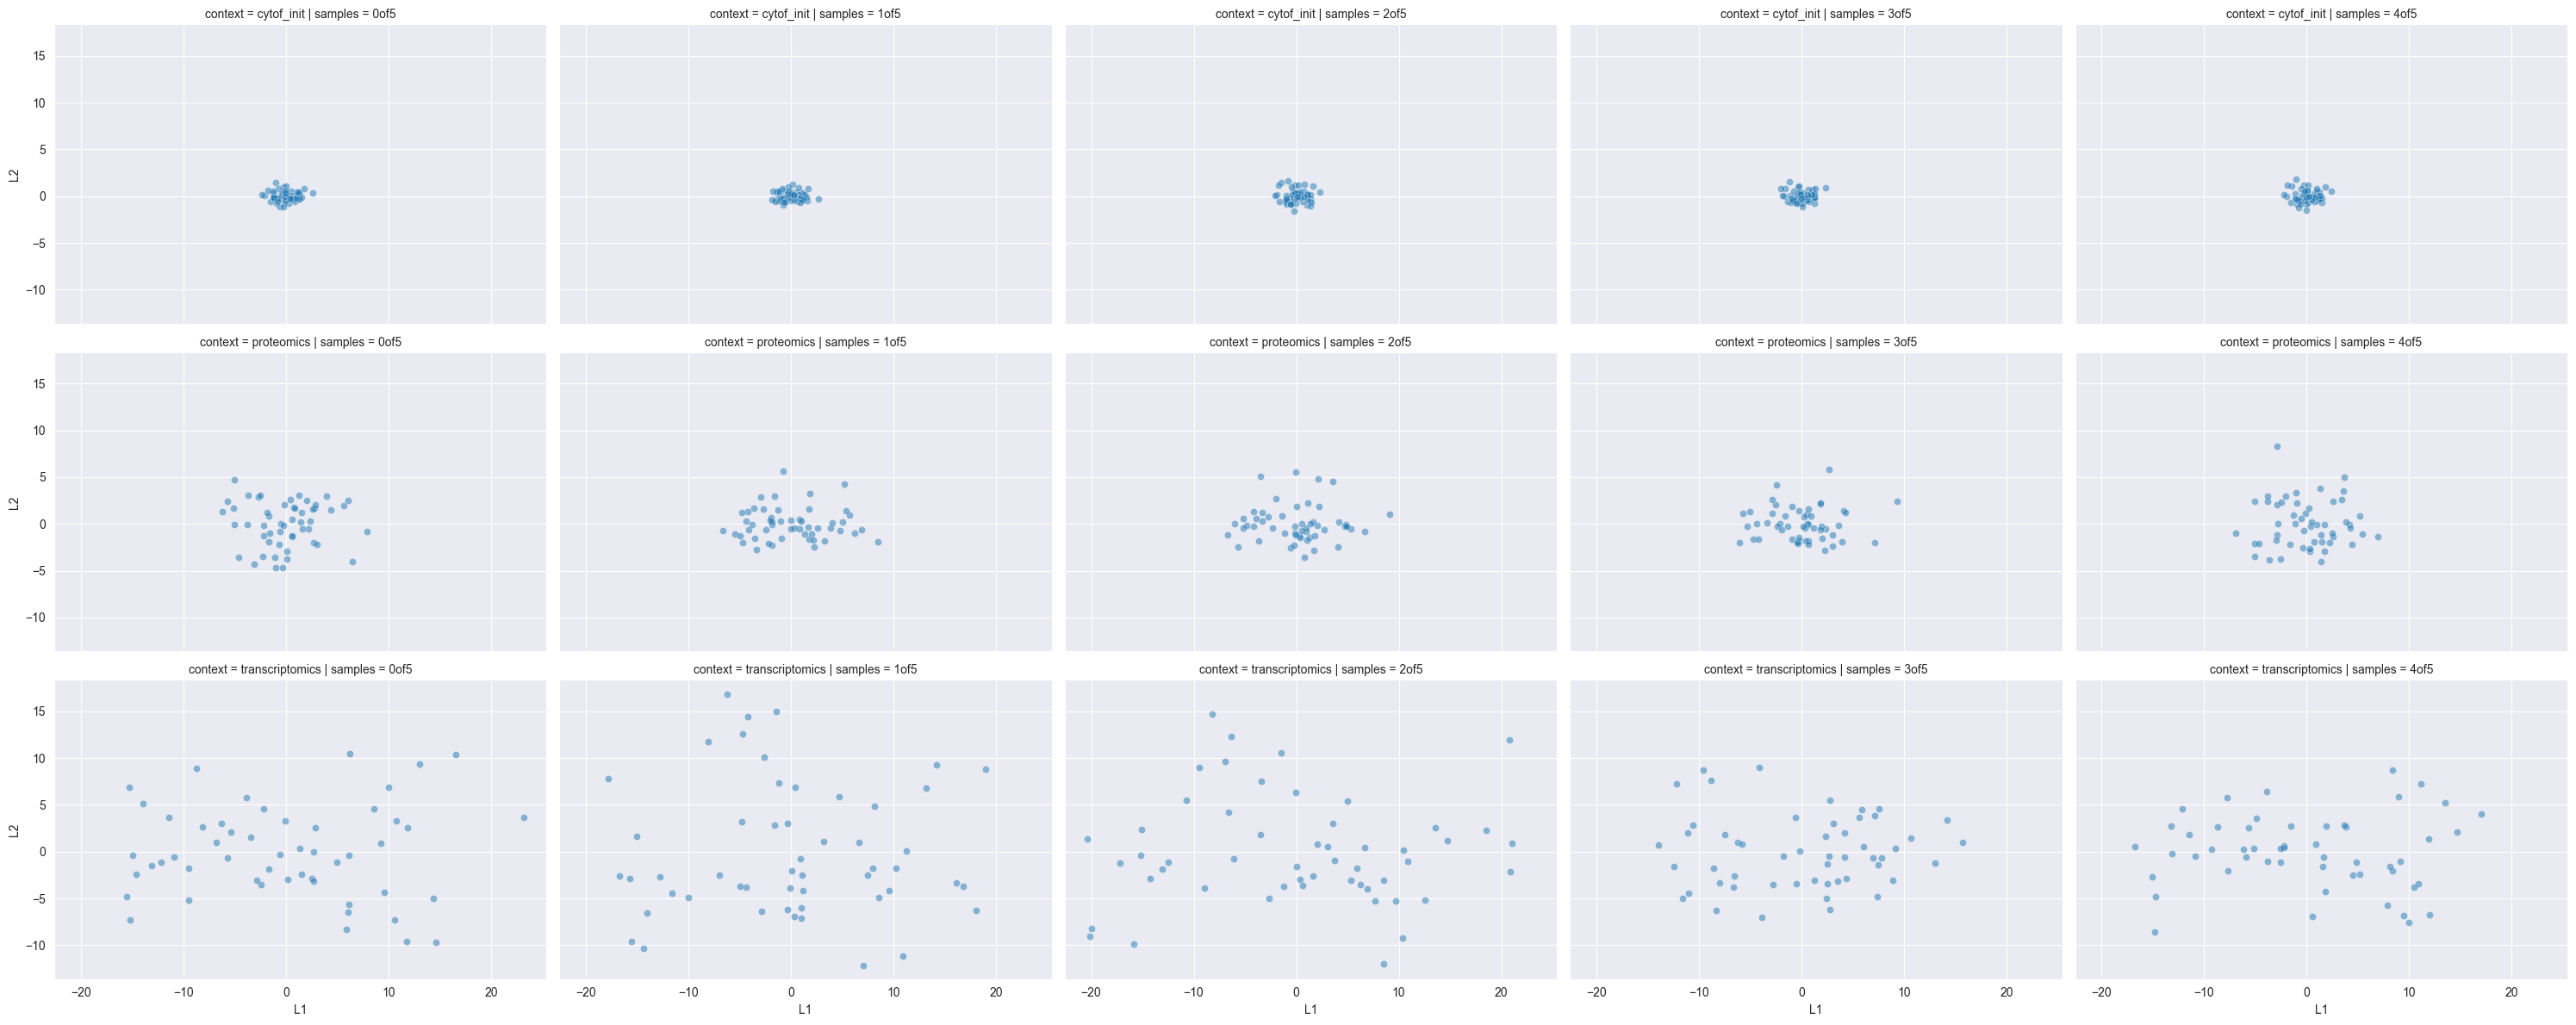

In [6]:
g = sns.FacetGrid(
    whole_pca_df,
    row="context",
    row_order=sorted(whole_pca_df["context"].unique()),
    col="samples",
    col_order=sorted(whole_pca_df["samples"].unique()),
    height=4,
    aspect=1.5
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    alpha=0.5
)

### Generate annotations for subtypes and protein markers.

In [7]:
samples_list = sorted(whole_pca_df.index.unique())
protein_markers = [
    "HER2",
    "HER3",  # all infs / NaNs
    "HER4",  # missing
    "CD44",
    "EPCAM",
    "CD24"
]  # CD133 is just NaNs and infs
uniprot_ids = [
    "P04626",   # HER2
    "P21860",  # HER3
    "Q15303",  # HER4
    "P16070",   # CD44
    "P16422",  # EPCAM
    "P25063",  # CD24
]

subtypes_pam50, subtypes_lb = generate_subtype_annotations(samples_list)
pher2_annotations, proteomics_annotations = generate_proteomics_annotations(
    protein_markers=protein_markers,
    uniprot_ids=uniprot_ids,
    samples_list=samples_list
)

Welcome, Giacomo Fabrini!




UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.8.0) is available. Your version (4.5.0) can be upgraded by typing:
    pip install --upgrade synapseclient

Python Synapse Client version 4.8.0 release notes

https://python-docs.synapse.org/news/



Marker HER4 not found with exception 'Q15303'.
Marker CD24 not found with exception 'P25063'.


In [8]:
import numpy as np
annotated_pca_df = annotate_pca_embeddings_with_metadata(
    pca_embedding_df=whole_pca_df.reset_index(),
    subtypes_pam50=subtypes_pam50,
    subtypes_lb=subtypes_lb,
    pher2_annotations=pher2_annotations,
    proteomarker_log2fc_annotations=proteomics_annotations
)
annotated_pca_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [9]:
# Loop through annotation variables
annotation_vars = (["HER2_log2FC", "EPCAM_log2FC", "CD44_log2FC"]
                   + list(pher2_annotations.keys())
                   + ["subtype_pam50", "subtype_lb"])

# Compute per-context max absolute values for L1 and L2
context_limits = annotated_pca_df.groupby("context").agg({
    "L1": lambda x: abs(x).max(),
    "L2": lambda x: abs(x).max()
}).rename(columns={"L1": "L1_max", "L2": "L2_max"}).to_dict("index")

for hue_var in annotation_vars:
    is_categorical = annotated_pca_df[hue_var].dtype == object or annotated_pca_df[hue_var].nunique() < 20

    scatter_func = make_annotation_scatter(hue_var, is_categorical, context_limits)

    g = sns.FacetGrid(
        annotated_pca_df,
        col="context",
        col_order=sorted(annotated_pca_df["context"].unique()),
        row="samples",
        row_order=sorted(annotated_pca_df["samples"].unique()),
        sharex=False,
        sharey=False,
        height=4,
        aspect=1.5
    )
    g.map_dataframe(scatter_func)

    if is_categorical:
        g.add_legend(title=hue_var)
        g._legend.set_bbox_to_anchor((1.02, 0.5))
        g._legend.set_frame_on(False)

    if not is_categorical:
        norm = mcolors.Normalize(
            vmin=annotated_pca_df[hue_var].min(),
            vmax=annotated_pca_df[hue_var].max()
        )
        cmap = "coolwarm"
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        g.fig.subplots_adjust(right=0.92)
        cbar_ax = g.fig.add_axes([0.93, 0.3, 0.02, 0.4])
        g.fig.colorbar(sm, cax=cbar_ax, label=hue_var)

    plt.savefig(f"pca_embeddings_by_{hue_var}.pdf", dpi=300, bbox_inches='tight')
    plt.close()

[WARNING] /Users/fabring/Desktop/DeepMechanisticModels/evaluation_plotting.py:728: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(

[WARNING] /Users/fabring/Desktop/DeepMechanisticModels/evaluation_plotting.py:728: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(

[WARNING] /Users/fabring/Desktop/DeepMechanisticModels/evaluation_plotting.py:728: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(



In [10]:
# Define marker categorical status and palette
markers_info = {
    "HER2_log2FC": False,
    "EPCAM_log2FC": False,
    "CD44_log2FC": False,
    "pHER2_raw": False,
    "pHER2_log2FC": False,
    "subtype_pam50": True,
    "subtype_lb": True,
}

palette = {
    "HER2_log2FC": "darkorange",
    "EPCAM_log2FC": "blue",
    "CD44_log2FC": "cyan",
    "pHER2_raw": "firebrick",
    "pHER2_log2FC": "red",
    "subtype_pam50": "goldenrod",
    "subtype_lb": "violet"
}

### SVM Classification Accuracy

---HER2_log2FC---
cytof_init         0.403846
proteomics         0.338462
transcriptomics    0.165385
Name: svm_accuracy, dtype: float64
---EPCAM_log2FC---
cytof_init         0.387234
proteomics         0.370213
transcriptomics    0.293617
Name: svm_accuracy, dtype: float64
---CD44_log2FC---
cytof_init         0.390244
proteomics         0.400000
transcriptomics    0.243902
Name: svm_accuracy, dtype: float64
---pHER2_raw---
cytof_init         0.531579
proteomics         0.305263
transcriptomics    0.226316
Name: svm_accuracy, dtype: float64
---pHER2_log2FC---
cytof_init         0.625641
proteomics         0.389744
transcriptomics    0.292308
Name: svm_accuracy, dtype: float64
---subtype_pam50---
cytof_init         0.476923
proteomics         0.453846
transcriptomics    0.296154
Name: svm_accuracy, dtype: float64
---subtype_lb---
cytof_init         0.680769
proteomics         0.715385
transcriptomics    0.357692
Name: svm_accuracy, dtype: float64


[WARNING] /Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)

[WARNING] /Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)

[WARNING] /Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)

[

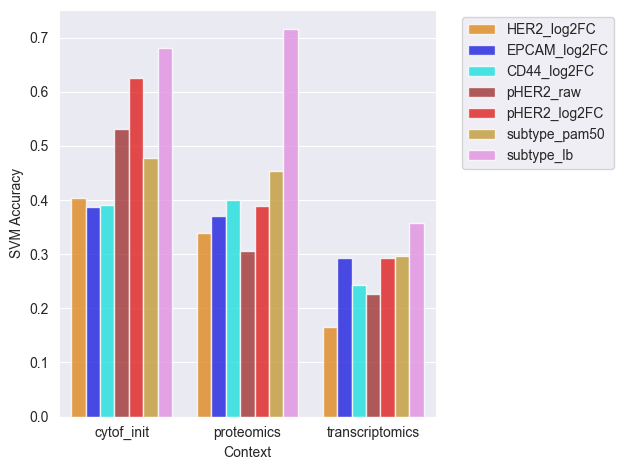

In [11]:
dfs = []
for marker, is_categorical in markers_info.items():
    print(f"---{marker}---")
    svm_accuracy = evaluate_svm_classifier_per_context(
        annotated_pca_df,
        metric=marker,
        strategy="quartiles_multi" if not markers_info[marker] else "categorical",
        n_splits=5,
    )
    print(svm_accuracy)

    # Attach marker name and the type of score (for plotting/labeling)
    svm_accuracy = svm_accuracy.reset_index()
    svm_accuracy["marker"] = marker
    dfs.append(svm_accuracy)

# Concatenate all accuracy results into a single dataframe
svm_df = pd.concat(dfs, axis=0).rename(columns={"index": "context"}).reset_index(drop=True)

sns.barplot(
    svm_df,
    x="context",
    y="svm_accuracy",
    hue="marker",
    palette=palette,
    alpha=0.8
).set_ylabel("SVM Accuracy")
plt.xlabel("Context")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig(f"svm_classifier_accuracy.pdf")
plt.show()

### Local Neighbourhood Smoothness

[WARNING] /Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)

[WARNING] /Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)

[WARNING] /Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)

[

---HER2_log2FC---
cytof_init         0.253869
proteomics         0.329337
transcriptomics    0.345910
Name: normalized_rmsd, dtype: float64
---EPCAM_log2FC---
cytof_init         0.252645
proteomics         0.276387
transcriptomics    0.271953
Name: normalized_rmsd, dtype: float64
---CD44_log2FC---
cytof_init         0.314290
proteomics         0.321222
transcriptomics    0.415701
Name: normalized_rmsd, dtype: float64
---pHER2_raw---
cytof_init         0.137206
proteomics         0.223890
transcriptomics    0.268611
Name: normalized_rmsd, dtype: float64
---pHER2_log2FC---
cytof_init         0.127727
proteomics         0.215939
transcriptomics    0.260962
Name: normalized_rmsd, dtype: float64
---subtype_pam50---
cytof_init         0.490000
proteomics         0.596923
transcriptomics    0.700000
Name: mean_disagreement, dtype: float64
---subtype_lb---
cytof_init         0.291538
proteomics         0.343077
transcriptomics    0.520000
Name: mean_disagreement, dtype: float64


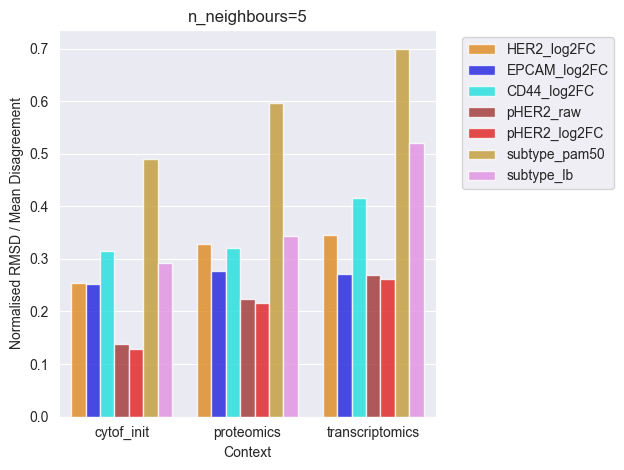

In [15]:
n_neighbours = 5

dfs = []

for marker, is_categorical in markers_info.items():
    print(f"---{marker}---")
    smoothness = compute_local_marker_smoothness(
        annotated_pca_df,
        n_neighbors=n_neighbours,
        marker=marker,
        is_categorical=is_categorical
    )
    print(smoothness)

    # Attach marker name and the type of score (for plotting/labeling)
    smoothness_df = smoothness.reset_index().rename(columns={smoothness.name: "smoothness_score"})
    smoothness_df["marker"] = marker
    smoothness_df["score_type"] = "disagreement" if is_categorical else "normalized_rmsd"
    dfs.append(smoothness_df)

# Concatenate all smoothness results into a single dataframe
rmsd_df = pd.concat(dfs, axis=0).rename(columns={"index": "context"}).reset_index(drop=True)

sns.barplot(
    rmsd_df,
    x="context",
    y="smoothness_score",
    hue="marker",
    palette=palette,
    alpha=0.8
).set_ylabel("Normalised RMSD / Mean Disagreement")
plt.xlabel("Context")
plt.title(f"n_neighbours={n_neighbours}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# plt.savefig(f"embedding_local_smoothness.pdf")